In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    HeatmapAnalyzer,
    FocusMapAnalyzer,
    FixationAnalyzer,
    SaccadeAnalyzer,
    EntropyAnalyzer,
    ClusterAnalyzer,
    ScanpathsAnalyzer,
)


config = CustomConfig('./configs/config.yaml')
loader = DataLoader(config, root='./')

▶ Global heatmap statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-171.993103,-1.810345,290


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260918_165832,-171.993103,-1.810345,290


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260918_165832,0,-48.487179,-3.230769,117
1,20260918_165832,1,-225.647887,1.929577,71
2,20260918_165832,2,-276.313725,-2.784314,102


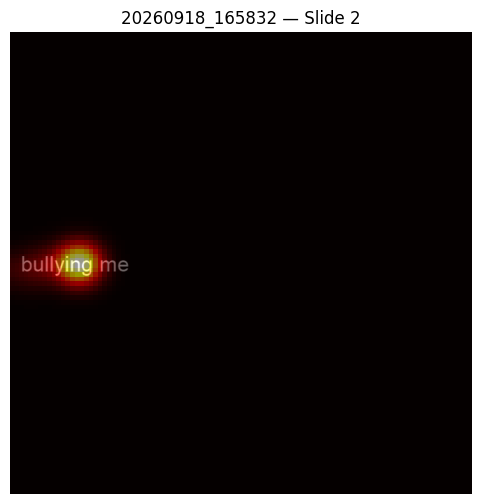

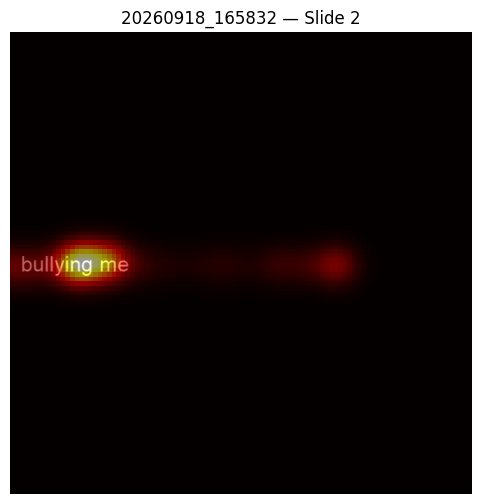

In [3]:
# Assuming you already have the data
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

analyzer = HeatmapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global heatmap statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# --- Plot heatmap for one image ---
example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


▶ Global focus map statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-171.993103,-1.810345,290


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260918_165832,-171.993103,-1.810345,290


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260918_165832,0,-48.487179,-3.230769,117
1,20260918_165832,1,-225.647887,1.929577,71
2,20260918_165832,2,-276.313725,-2.784314,102


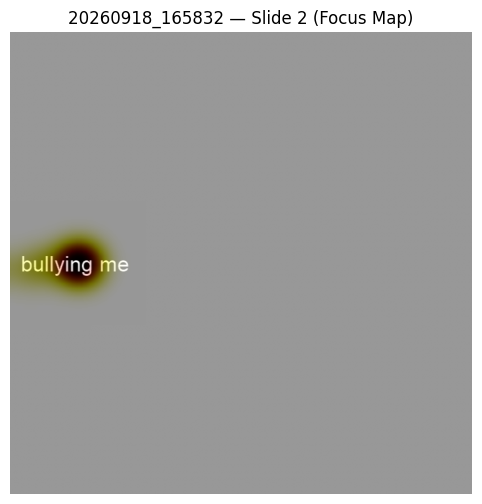

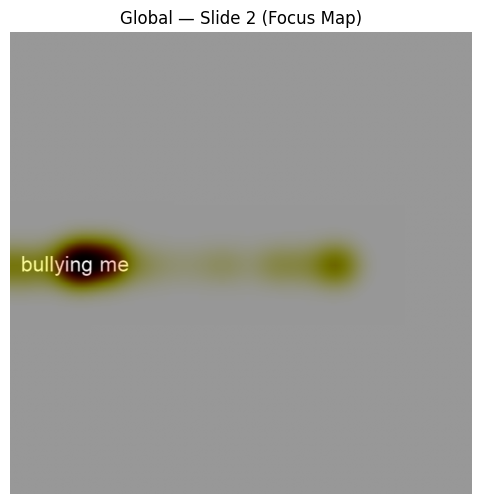

In [4]:
# --- Prepare background data ---
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

analyzer = FocusMapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global focus map statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# ============================================================
# 🖼 Plot focus map for one example slide
# ============================================================

example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

# --- Focus map for single slide (individual subject) ---
analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']} (Focus Map)",
)

# --- Focus map using all gaze data for this slide (across subjects) ---
analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"Global — Slide {example_slide['slide_index']} (Focus Map)",
)

▶ Detecting saccades...


,set_name,slide_index,start_time,end_time,duration,x_start,y_start,x_end,y_end,amplitude,peak_velocity,mean_velocity,mean_acceleration
0,20260918_165832,0,10.976656,11.113457,0.151698,-351.0,-1.0,-284.0,-1.0,67.000000,890.173173,501.738297,13362.158072
1,20260918_165832,0,11.159631,11.159631,0.016719,-276.0,-1.0,-274.0,-1.0,2.000000,119.622948,119.622948,7059.362781
2,20260918_165832,0,11.192501,11.192501,0.017860,-270.0,-1.0,-269.0,-1.0,1.000000,55.991668,55.991668,11785.500782
3,20260918_165832,0,11.237051,11.533454,0.311797,-256.0,-1.0,-171.0,0.0,85.005882,772.325839,279.066129,8855.604946
4,20260918_165832,0,11.580997,12.109554,0.560513,-169.0,0.0,51.0,-6.0,220.081803,1025.529269,400.884981,9055.347273


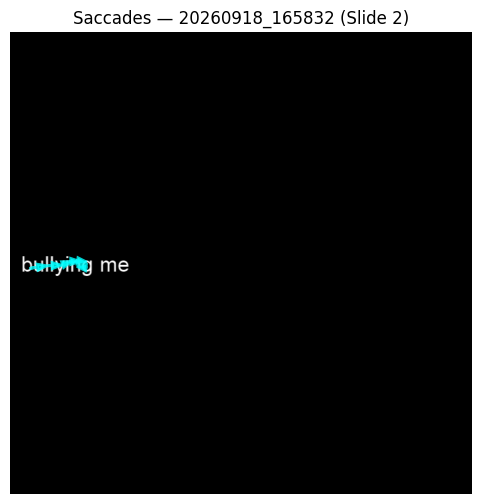

In [5]:
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

saccade_analyzer = SaccadeAnalyzer(
    output_folder=output_dir,
    method="ivt",               # "ivt" (velocity-based) or "acceleration"
    velocity_threshold=120.0,   # pixels/sec
    acceleration_threshold=6000.0,  # pixels/sec^2
    min_duration=0.015,         # seconds
)

print("▶ Detecting saccades...")
saccades = saccade_analyzer.analyze(background_data)
display(saccades.head())

example_slide = background_data.iloc[-1]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

saccade_analyzer.plot_analysis(
    saccades=saccades,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Saccades — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Detecting fixations...


,fix_start,fix_end,duration,x_mean,y_mean,dispersion,set_name,slide_index
0,10.790073,11.038938,0.248865,-348.230769,-1.615385,71.0,20260918_165832,0
1,11.054399,11.269634,0.215235,-267.916667,-0.666667,65.0,20260918_165832,0
2,11.299150,11.580997,0.281846,-194.200000,0.466667,63.0,20260918_165832,0
3,11.597029,11.753196,0.156167,-132.000000,-1.111111,64.0,20260918_165832,0
4,11.768124,11.921864,0.153739,-53.250000,-4.500000,62.0,20260918_165832,0


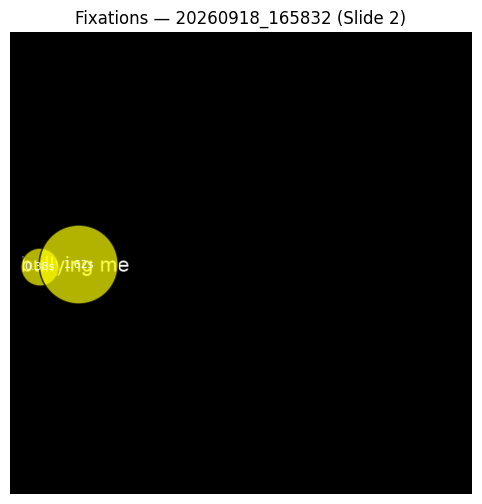

In [6]:
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

fixation_analyzer = FixationAnalyzer(
    output_folder=output_dir,
    method="dispersion",           # or "velocity"
    dispersion_threshold=60.0,     # pixels
    min_duration=0.08,             # seconds
)

print("▶ Detecting fixations...")
fixations = fixation_analyzer.analyze(background_data)
display(fixations.head())

example_slide = background_data.iloc[-1]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

fixation_analyzer.plot_analysis(
    fixations=fixations,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Fixations — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

In [7]:
background_data.head()

,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,objects_bboxes,voice_file,voice_start_timestamp,...,system_time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size
0,20260918_165832,0,"output\20260918_165832\I`d_have_responded,_.png","I`d have responded, if I were going",neutral,neutral,None,"{'words': [{'word': 'I`d', 'conf': 1.0, 'bbox'...",NaN,NaN,...,10.790073,-364.0,-2.0,None,None,5,0,-364.0,-2.0,2.5
1,20260918_165832,0,"output\20260918_165832\I`d_have_responded,_.png","I`d have responded, if I were going",neutral,neutral,None,"{'words': [{'word': 'I`d', 'conf': 1.0, 'bbox'...",NaN,NaN,...,10.821618,-364.0,-2.0,None,None,5,0,-364.0,-2.0,2.5
2,20260918_165832,0,"output\20260918_165832\I`d_have_responded,_.png","I`d have responded, if I were going",neutral,neutral,None,"{'words': [{'word': 'I`d', 'conf': 1.0, 'bbox'...",NaN,NaN,...,10.836792,-364.0,-2.0,None,None,5,0,-364.0,-2.0,2.5
3,20260918_165832,0,"output\20260918_165832\I`d_have_responded,_.png","I`d have responded, if I were going",neutral,neutral,None,"{'words': [{'word': 'I`d', 'conf': 1.0, 'bbox'...",NaN,NaN,...,10.853210,-364.0,-2.0,None,None,5,0,-364.0,-2.0,2.5
4,20260918_165832,0,"output\20260918_165832\I`d_have_responded,_.png","I`d have responded, if I were going",neutral,neutral,None,"{'words': [{'word': 'I`d', 'conf': 1.0, 'bbox'...",NaN,NaN,...,10.883952,-364.0,-2.0,None,None,5,0,-364.0,-2.0,2.5


▶ Performing gaze clustering...


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,objects_bboxes,voice_file,voice_start_timestamp,...,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size,cluster
0,20260918_165832,2,output\20260918_165832\bullying_me.png,bullying me,negative,negative,None,"{'words': [{'word': 'bullying', 'conf': 1.0, '...",NaN,NaN,...,-348.0,-10.0,None,None,5,0,-348.0,-10.0,2.5,0
1,20260918_165832,2,output\20260918_165832\bullying_me.png,bullying me,negative,negative,None,"{'words': [{'word': 'bullying', 'conf': 1.0, '...",NaN,NaN,...,-348.0,-10.0,None,None,5,0,-348.0,-10.0,2.5,0
2,20260918_165832,2,output\20260918_165832\bullying_me.png,bullying me,negative,negative,None,"{'words': [{'word': 'bullying', 'conf': 1.0, '...",NaN,NaN,...,-348.0,-10.0,None,None,5,0,-348.0,-10.0,2.5,0
3,20260918_165832,2,output\20260918_165832\bullying_me.png,bullying me,negative,negative,None,"{'words': [{'word': 'bullying', 'conf': 1.0, '...",NaN,NaN,...,-348.0,-10.0,None,None,5,0,-348.0,-10.0,2.5,0
4,20260918_165832,2,output\20260918_165832\bullying_me.png,bullying me,negative,negative,None,"{'words': [{'word': 'bullying', 'conf': 1.0, '...",NaN,NaN,...,-348.0,-10.0,None,None,5,0,-348.0,-10.0,2.5,0


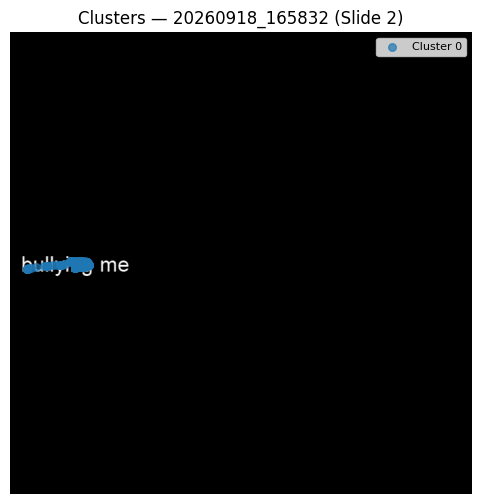

In [8]:
# ==============================================
# 👁️ Cluster Analyzer Demo
# ==============================================
from pathlib import Path
import pandas as pd

#background_data= loader.get_all_data(flatten=True)
background_data= loader.get_slide_data(loader.get_subjects()[-1],-1,flatten=True)
output_dir = Path("./analysis_outputs")

# Instantiate analyzer (DBSCAN by default)
cluster_analyzer = ClusterAnalyzer(
    output_folder=output_dir,
    eps=20,              # pixel distance for clustering
    min_samples=3,        # minimum points per cluster
)

print("▶ Performing gaze clustering...")
clustered_data = cluster_analyzer.analyze(background_data)
display(clustered_data.head())

# --- Visualization for one slide ---
example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

cluster_analyzer.plot_analysis(
    background_data=clustered_data,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Clusters — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Slide-level entropy


,entropy,convex_hull_area,num_points,set_name,slide_index
0,5.564273,1907.0,117,20260918_165832,0
1,4.570917,364.5,71,20260918_165832,1
2,5.033843,683.0,102,20260918_165832,2


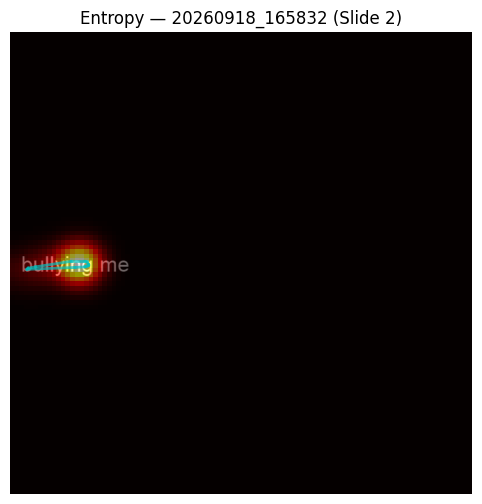

In [9]:
# ==============================================
# 🧠 Entropy Analyzer Demo
# ==============================================
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

entropy_analyzer = EntropyAnalyzer(output_folder=output_dir)

print("▶ Slide-level entropy")
entropy_results = entropy_analyzer.analyze(background_data, per="slide", bins=100, use_convex_hull=True)
display(entropy_results.head())

# --- Visualization for one example slide ---
example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

entropy_analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"Entropy — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)
